Saving PRSA_Data_Aotizhongxin_20130301-20170228.csv to PRSA_Data_Aotizhongxin_20130301-20170228.csv
Saving PRSA_Data_Changping_20130301-20170228.csv to PRSA_Data_Changping_20130301-20170228.csv
Saving PRSA_Data_Dingling_20130301-20170228.csv to PRSA_Data_Dingling_20130301-20170228.csv
Saving PRSA_Data_Dongsi_20130301-20170228.csv to PRSA_Data_Dongsi_20130301-20170228.csv
Saving PRSA_Data_Guanyuan_20130301-20170228.csv to PRSA_Data_Guanyuan_20130301-20170228.csv
Saving PRSA_Data_Gucheng_20130301-20170228.csv to PRSA_Data_Gucheng_20130301-20170228.csv
Saving PRSA_Data_Huairou_20130301-20170228.csv to PRSA_Data_Huairou_20130301-20170228.csv
Saving PRSA_Data_Nongzhanguan_20130301-20170228.csv to PRSA_Data_Nongzhanguan_20130301-20170228.csv
Saving PRSA_Data_Shunyi_20130301-20170228.csv to PRSA_Data_Shunyi_20130301-20170228.csv
Saving PRSA_Data_Tiantan_20130301-20170228.csv to PRSA_Data_Tiantan_20130301-20170228.csv
Saving PRSA_Data_Wanliu_20130301-20170228.csv to PRSA_Data_Wanliu_20130301-2

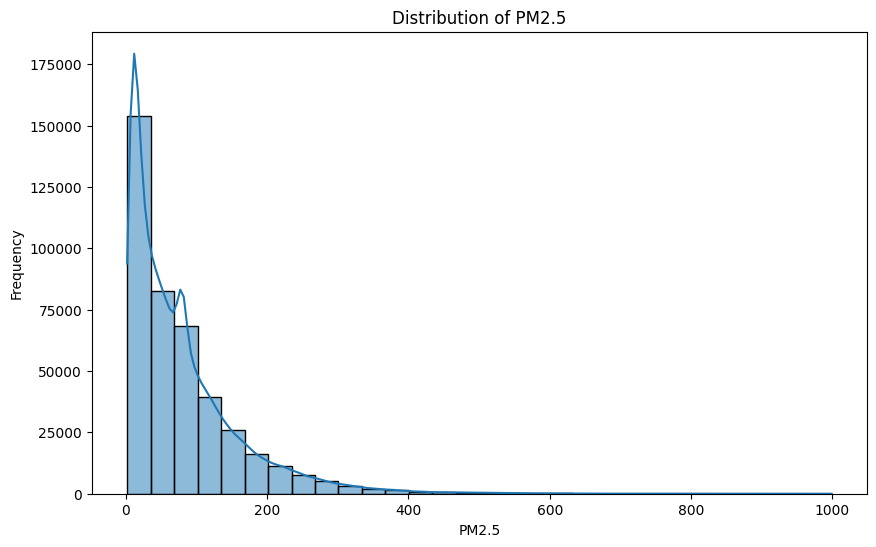

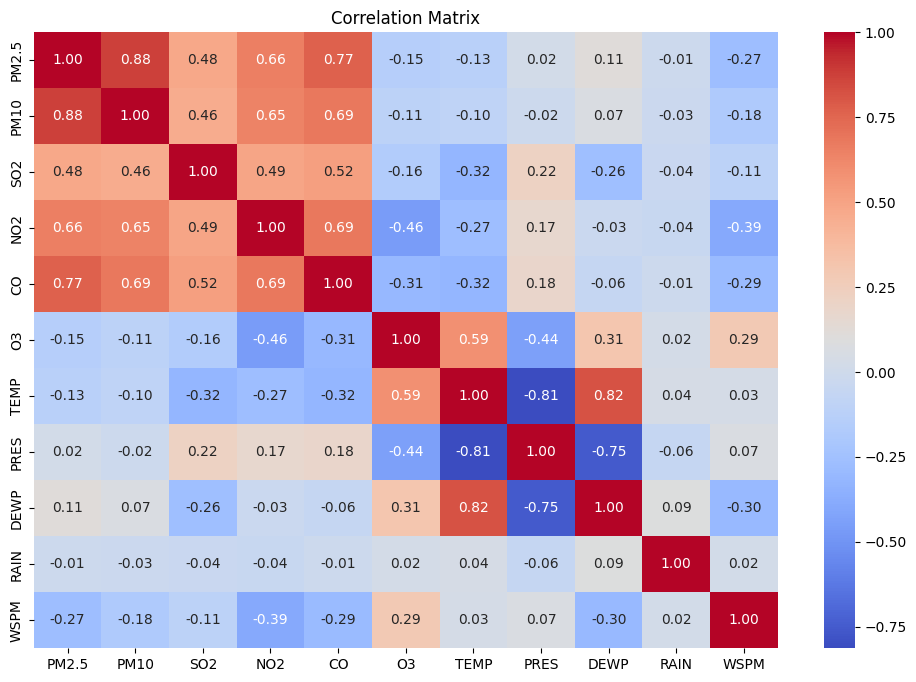

Variables Most Correlated with PM2.5:
PM2.5    1.000000
PM10     0.879389
CO       0.768664
NO2      0.658108
SO2      0.477582
DEWP     0.113499
PRES     0.018357
RAIN    -0.014156
TEMP    -0.129715
O3      -0.147204
WSPM    -0.269023
Name: PM2.5, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
from google.colab import files
import io

# Upload multiple files
uploaded = files.upload()

# Read and combine all uploaded CSV files
df_list = []
for filename in uploaded.keys():
    temp_df = pd.read_csv(io.BytesIO(uploaded[filename]))
    df_list.append(temp_df)

# Merge all files into one DataFrame
df = pd.concat(df_list, ignore_index=True)

# Display dataset information
print("Combined Dataset Shape:", df.shape)
print("\nFiles Loaded:", list(uploaded.keys()))
print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------
# Task 2: Data Cleaning
# -----------------------------
print('Missing Values Before Cleaning:')
print(df.isnull().sum())

# Fill missing numerical values with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Remove duplicates
df.drop_duplicates(inplace=True)

print('Missing Values After Cleaning:')
print(df.isnull().sum())

# -----------------------------
# Task 3: Basic Statistical Analysis
# -----------------------------
print('Descriptive Statistics:')
print(df.describe())

# Mean, Median, Min, Max, Standard Deviation
stats = df[numeric_cols].agg(['mean', 'median', 'min', 'max', 'std'])
print('Summary Statistics:')
print(stats)

# -----------------------------
# Task 4: Data Filtering
# -----------------------------
station_avg = df.groupby('station')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
print('Average Pollution Levels by Station:')
print(station_avg)

# -----------------------------
# Task 5: Data Visualization
# -----------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df['PM2.5'], bins=30, kde=True)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.show()

# -----------------------------
# Task 6: Correlation Analysis
# -----------------------------
# Define pollutants for correlation analysis (assuming these are the relevant columns)
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

correlation_matrix = df[pollutants + ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Correlation with PM2.5
pm25_corr = correlation_matrix['PM2.5'].sort_values(ascending=False)
print('Variables Most Correlated with PM2.5:')
print(pm25_corr)